## Distribution Analysis Notebook - Overview

This notebook provides comprehensive visualization and analysis of the PVA donor dataset distributions.

### Notebook Contents

1. **Data Loading & Preparation**
   - Load donor data from CSV
   - Identify feature columns (excluding targets and categorical)
   - Prepare data for visualization

2. **Histogram Analysis with Normal Curve**
   - 21 feature distributions displayed in 4-column grid
   - Y-axis: Percent (%) for business interpretation
   - Red line: Normal distribution overlay with μ and σ
   - Statistics box: N, Mean, Std Dev, Skewness, Kurtosis

3. **Density vs Percent Explanation**
   - Detailed guide on why we use percent instead of density
   - Mathematical relationships and interpretations
   - When to use each approach

4. **Probability Plots (Q-Q Plots)**
   - Visual normality assessment for all features
   - Identify skewness, outliers, and tail behavior
   - Red line: Theoretical normal distribution
   - Blue points: Actual data points

5. **One-Way Frequency Charts**
   - Categorical variable distributions
   - Includes: StatusCat96NK, StatusCatStarAll, Response, DemGender, DemHomeOwner
   - Shows counts and percentages
   - Identifies class imbalance

### Key Updates (August 23, 2026)

✅ **New Target Variables Added**
- `Response`: Binary (Yes/No) - Donor response indicator
- `Donation_Amt`: Continuous - Donation amount in dollars

✅ **Excluded from Feature Analysis**
- Target variables: Response, Donation_Amt
- Categorical: DemGender, DemHomeOwner
- Engineered features: Rep_DemMedIncome, IM_Rep_DemMedIncome, log_GiftCnt36

✅ **Updated Categorical Analysis**
- Now includes Response variable in frequency charts
- Better understanding of target distribution

### Dataset Summary
- **Total Records**: 9,686 donors
- **Features Analyzed**: 21 numeric features
- **Categorical Variables**: 5 (including Response)
- **Visualizations**: 21 histograms + 21 Q-Q plots + 5 frequency charts

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from pathlib import Path
# Disable Jupyter output truncation completely
from IPython.display import display
import sys

# Display with better formatting - all columns visible
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [70]:

print(Path.cwd())
# Gets the parent directory of the current working directory
project_root = Path.cwd().parent.parent

print(project_root)

/Users/gkumargaur/workspace/datascience/boston_university/datascience-practice/sas_hackthon/stats_ml
/Users/gkumargaur/workspace/datascience/boston_university/datascience-practice


In [71]:
fullpath = "{}/data/VST152/pva_donors.csv".format(project_root)
donor_data = pd.read_csv(fullpath)

In [72]:
# Exclude ID, StatusCat96NK (target), and StatusCatStarAll
exclude_cols = ['ID', 'StatusCat96NK', 'StatusCatStarAll', 'Response', 'DemGender', 'DemHomeOwner', 'Rep_DemMedIncome', 'IM_Rep_DemMedIncome', 'log_GiftCnt36']
numeric_cols = donor_data.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]



In [73]:
## Donation amount is the target variable for this analysis

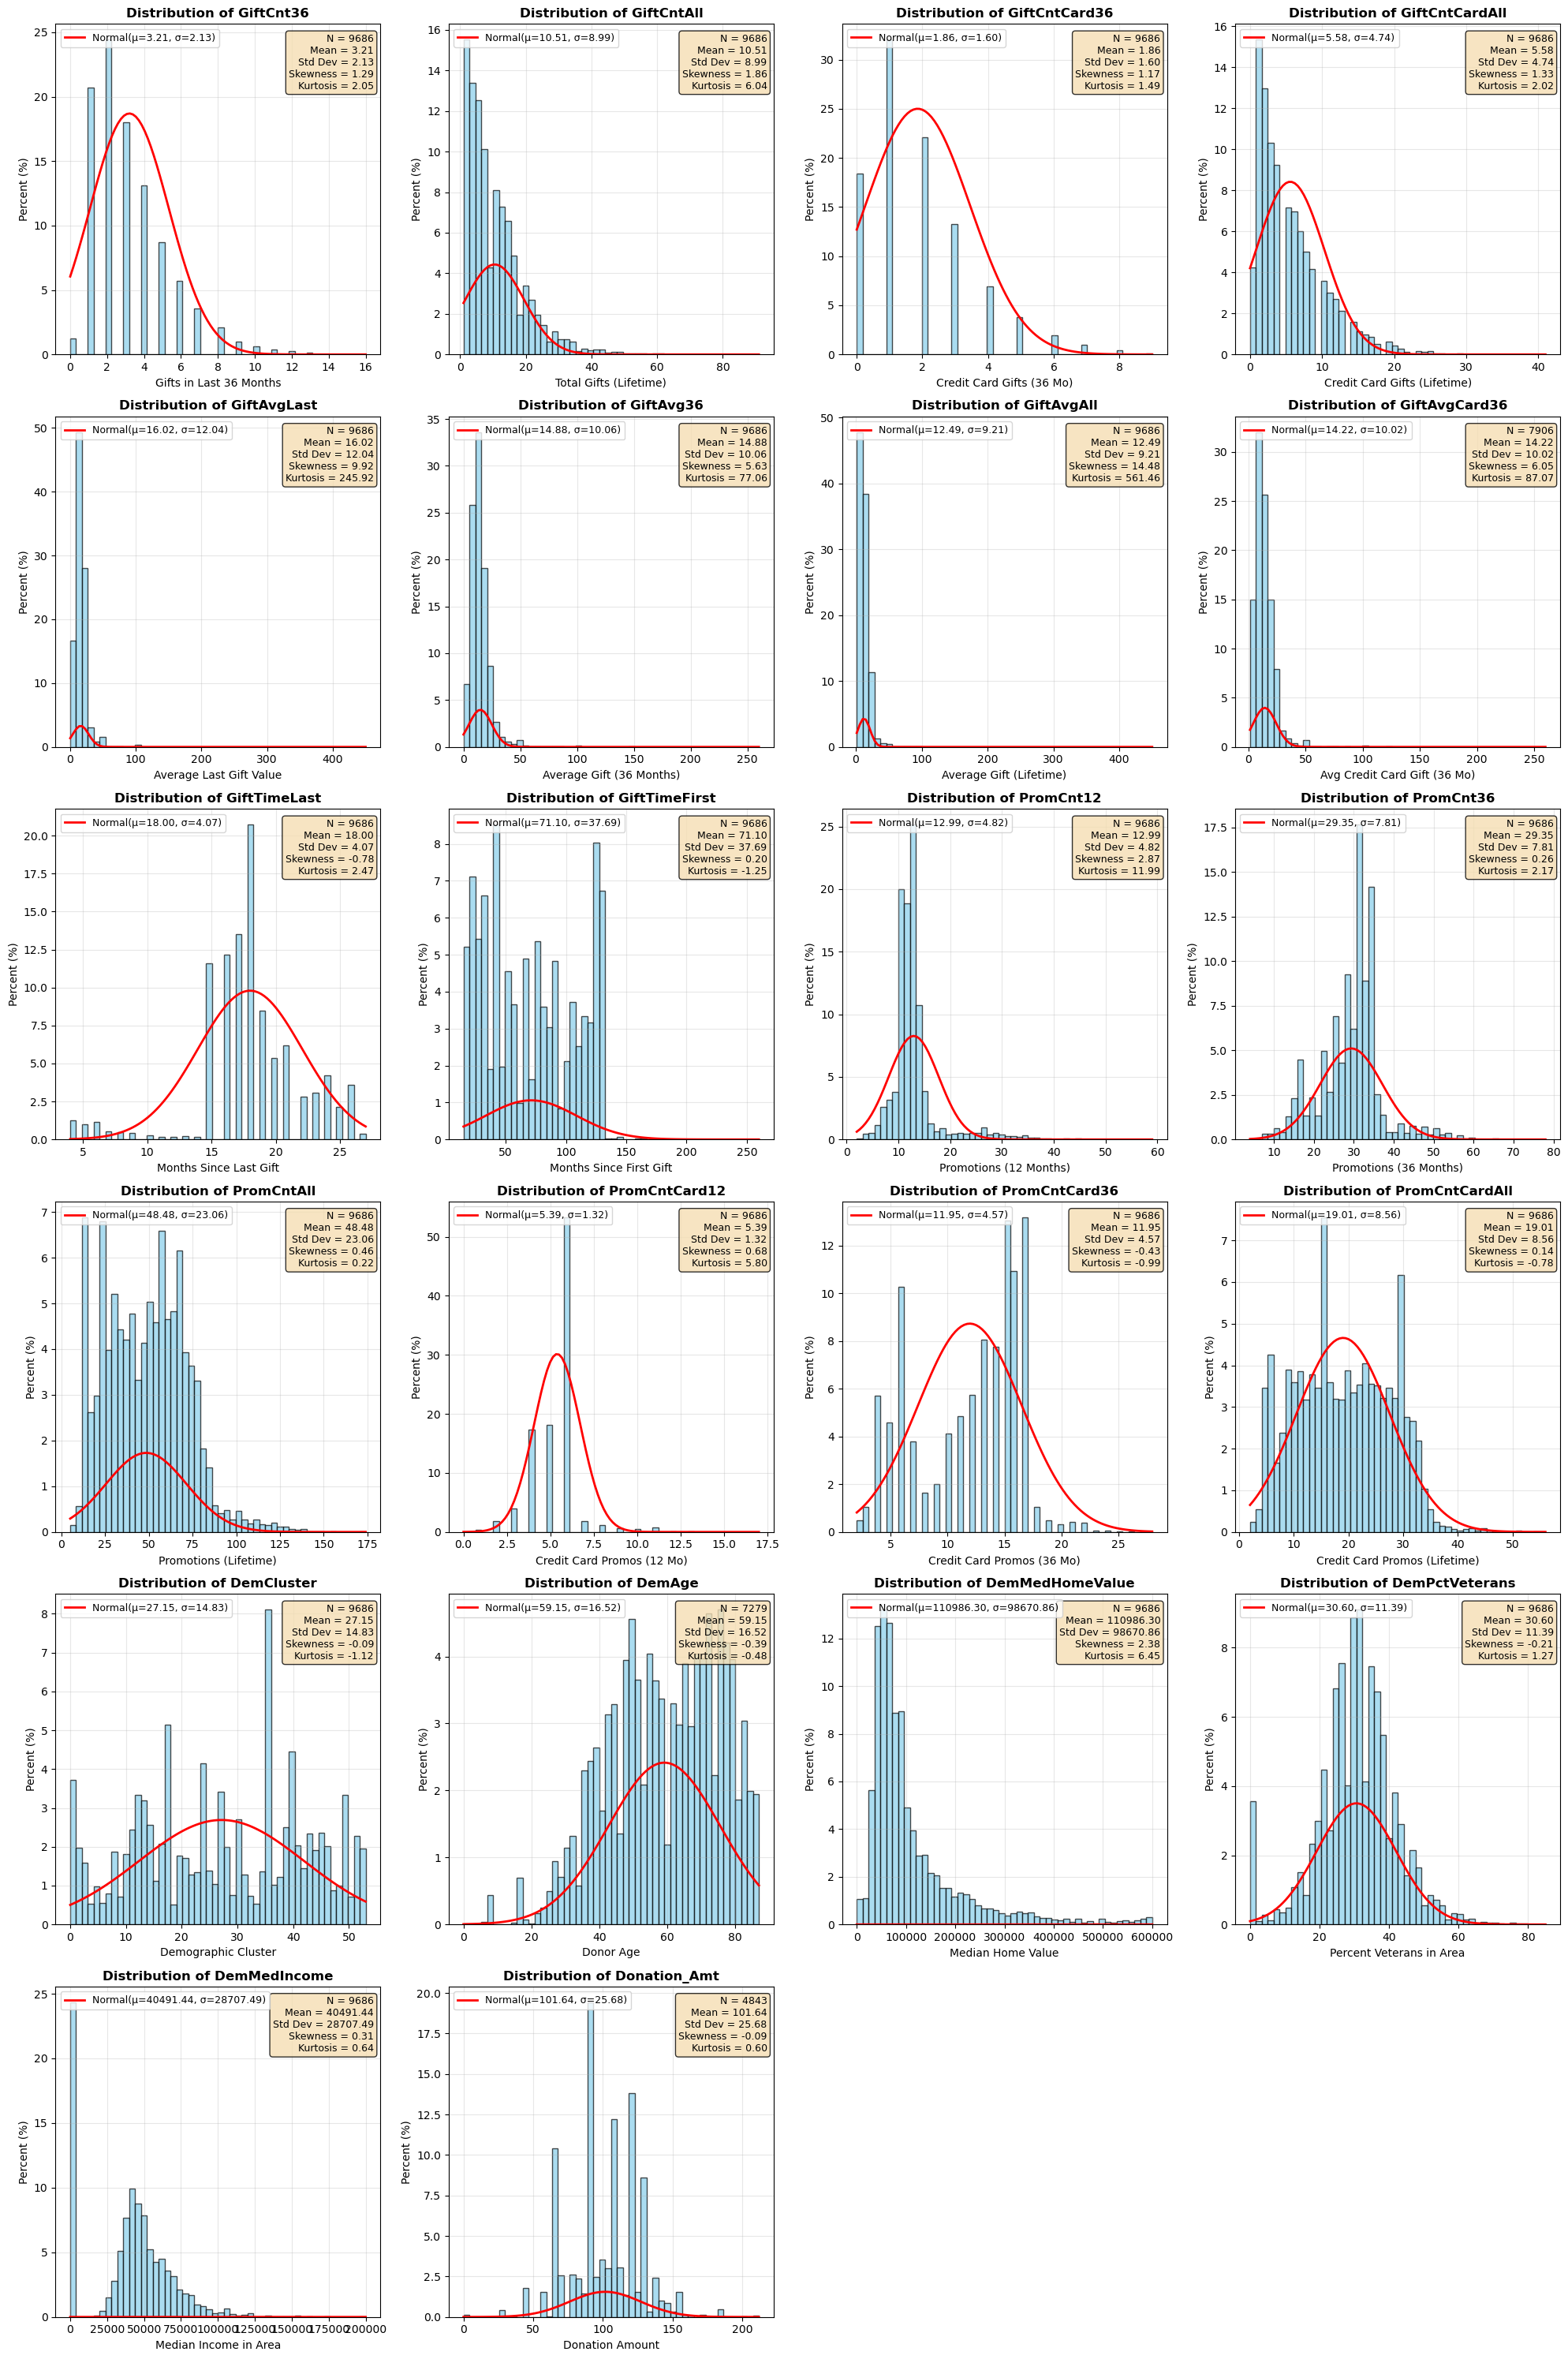

✓ Created histograms for 22 features
✓ Y-axis: Percent (%) - easier to interpret
✓ Grid layout: 6 rows × 4 columns
✓ Saved as 'feature_distributions.png'


In [74]:
# Create histograms for all features with statistics and normal curve overlay
# Format: Percent (%) on Y-axis, matching training video style

from scipy.stats import norm
from scipy import stats

# Column descriptions mapping
col_descriptions = {
    'GiftCnt36': 'Gifts in Last 36 Months',
    'GiftCntAll': 'Total Gifts (Lifetime)',
    'GiftCntCard36': 'Credit Card Gifts (36 Mo)',
    'GiftCntCardAll': 'Credit Card Gifts (Lifetime)',
    'GiftAvgLast': 'Average Last Gift Value',
    'GiftAvg36': 'Average Gift (36 Months)',
    'GiftAvgAll': 'Average Gift (Lifetime)',
    'GiftAvgCard36': 'Avg Credit Card Gift (36 Mo)',
    'GiftTimeLast': 'Months Since Last Gift',
    'GiftTimeFirst': 'Months Since First Gift',
    'PromCnt12': 'Promotions (12 Months)',
    'PromCnt36': 'Promotions (36 Months)',
    'PromCntAll': 'Promotions (Lifetime)',
    'PromCntCard12': 'Credit Card Promos (12 Mo)',
    'PromCntCard36': 'Credit Card Promos (36 Mo)',
    'PromCntCardAll': 'Credit Card Promos (Lifetime)',
    'DemCluster': 'Demographic Cluster',
    'DemAge': 'Donor Age',
    'DemMedHomeValue': 'Median Home Value',
    'DemPctVeterans': 'Percent Veterans in Area',
    'DemMedIncome': 'Median Income in Area',
    'Donation_Amt': 'Donation Amount'
}

# Create subplots - 4 columns, calculate rows needed
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    data = donor_data[col].dropna()
    
    # Get statistics
    n = len(data)
    mean = data.mean()
    std = data.std()
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)
    
    # Plot histogram with PERCENT (not density)
    # weights parameter converts counts to percentages
    counts, bins, patches = ax.hist(data, bins=50, weights=np.ones(len(data))/len(data)*100, 
                                     alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution curve (scaled to percent)
    x = np.linspace(data.min(), data.max(), 100)
    normal_curve = norm.pdf(x, mean, std) * 100  # Scale to percent
    ax.plot(x, normal_curve, 'r-', linewidth=2, label=f'Normal(μ={mean:.2f}, σ={std:.2f})')
    
    # Get column description
    description = col_descriptions.get(col, col)
    
    # Set title and labels - matching training video format
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(description, fontsize=10)
    ax.set_ylabel('Percent (%)', fontsize=10)
    
    # Create legend with statistics
    legend_text = f'N = {n}\nMean = {mean:.2f}\nStd Dev = {std:.2f}\nSkewness = {skewness:.2f}\nKurtosis = {kurtosis:.2f}'
    ax.text(0.98, 0.97, legend_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Created histograms for {n_features} features")
print(f"✓ Y-axis: Percent (%) - easier to interpret")
print(f"✓ Grid layout: {n_rows} rows × {n_cols} columns")
print(f"✓ Saved as 'feature_distributions.png'")

## Understanding Density vs Percent in Histograms

### Quick Comparison

| Aspect | Density | Percent |
|--------|---------|---------|
| **Y-axis Range** | 0 to ~1 (or higher) | 0 to 100% |
| **Interpretation** | Probability per unit width | Percentage of total observations |
| **Area Under Curve** | Always equals 1.0 | Always equals 100% |
| **Use Case** | Statistical/theoretical analysis | Business/non-technical audiences |
| **Normal Curve Fit** | Fits perfectly on same scale | Needs scaling adjustment |
| **Readability** | Less intuitive | More intuitive |

---

## Detailed Explanation with Example

### Scenario
You have **100 donors** and want to visualize how many gifts they gave:
- **Bin 1** (1-2 gifts): 20 donors
- **Bin 2** (3-4 gifts): 30 donors
- **Bin 3** (5-6 gifts): 25 donors
- **Bin 4** (7+ gifts): 25 donors

### Density Representation

```
Y-axis shows: Probability Density (area under histogram = 1.0)

Bin 1: height = 0.20  (20% of data, but shown as 0.20 on density scale)
Bin 2: height = 0.30  (30% of data, but shown as 0.30 on density scale)
Bin 3: height = 0.25  (25% of data, but shown as 0.25 on density scale)
Bin 4: height = 0.25  (25% of data, but shown as 0.25 on density scale)

Total area = 0.20 + 0.30 + 0.25 + 0.25 = 1.0 ✓
```

**Interpretation:** "The probability of a randomly selected donor falling in Bin 1 is 0.20"

### Percent Representation

```
Y-axis shows: Percentage (%) (area under histogram = 100%)

Bin 1: height = 20%   (20 out of 100 donors)
Bin 2: height = 30%   (30 out of 100 donors)
Bin 3: height = 25%   (25 out of 100 donors)
Bin 4: height = 25%   (25 out of 100 donors)

Total area = 20% + 30% + 25% + 25% = 100% ✓
```

**Interpretation:** "20% of donors gave 1-2 gifts" (much clearer!)

---

## Why Use Each?

### Use **Density** When:
- ✅ Overlaying theoretical distributions (normal, exponential, etc.)
- ✅ Performing statistical hypothesis testing
- ✅ Comparing multiple distributions with different scales
- ✅ Working with probability theory
- ✅ Academic/research papers

**Example:** Comparing actual data distribution with a theoretical normal distribution

### Use **Percent** When:
- ✅ Presenting to business stakeholders
- ✅ Creating reports for non-technical audiences
- ✅ Explaining data insights in simple terms
- ✅ Making business decisions based on data
- ✅ Training videos and educational content

**Example:** "30% of our donors are inactive" is clearer than "density = 0.30"

---

## Mathematical Relationship

```
Percent = Density × 100 × Bin Width

For our example with equal bin widths:
Density of Bin 1 = 0.20
Percent of Bin 1 = 0.20 × 100 = 20%
```

---

## Visual Comparison

### Density Scale
```
     |
0.30 |     ███
     |     ███
0.20 | ███ ███ ███ ███
     | ███ ███ ███ ███
0.10 | ███ ███ ███ ███
     |_________________
       Bin1 Bin2 Bin3 Bin4
```

### Percent Scale
```
     |
 30% |     ███
     |     ███
 20% | ███ ███ ███ ███
     | ███ ███ ███ ███
 10% | ███ ███ ███ ███
     |_________________
       Bin1 Bin2 Bin3 Bin4
```

**Same data, different interpretation!**

---

## Key Takeaway

- **Density** = "What's the probability?" (mathematical perspective)
- **Percent** = "What percentage of data?" (business perspective)

For this analysis, we use **Percent** because it's more intuitive and aligns with how business stakeholders think about donor segments.

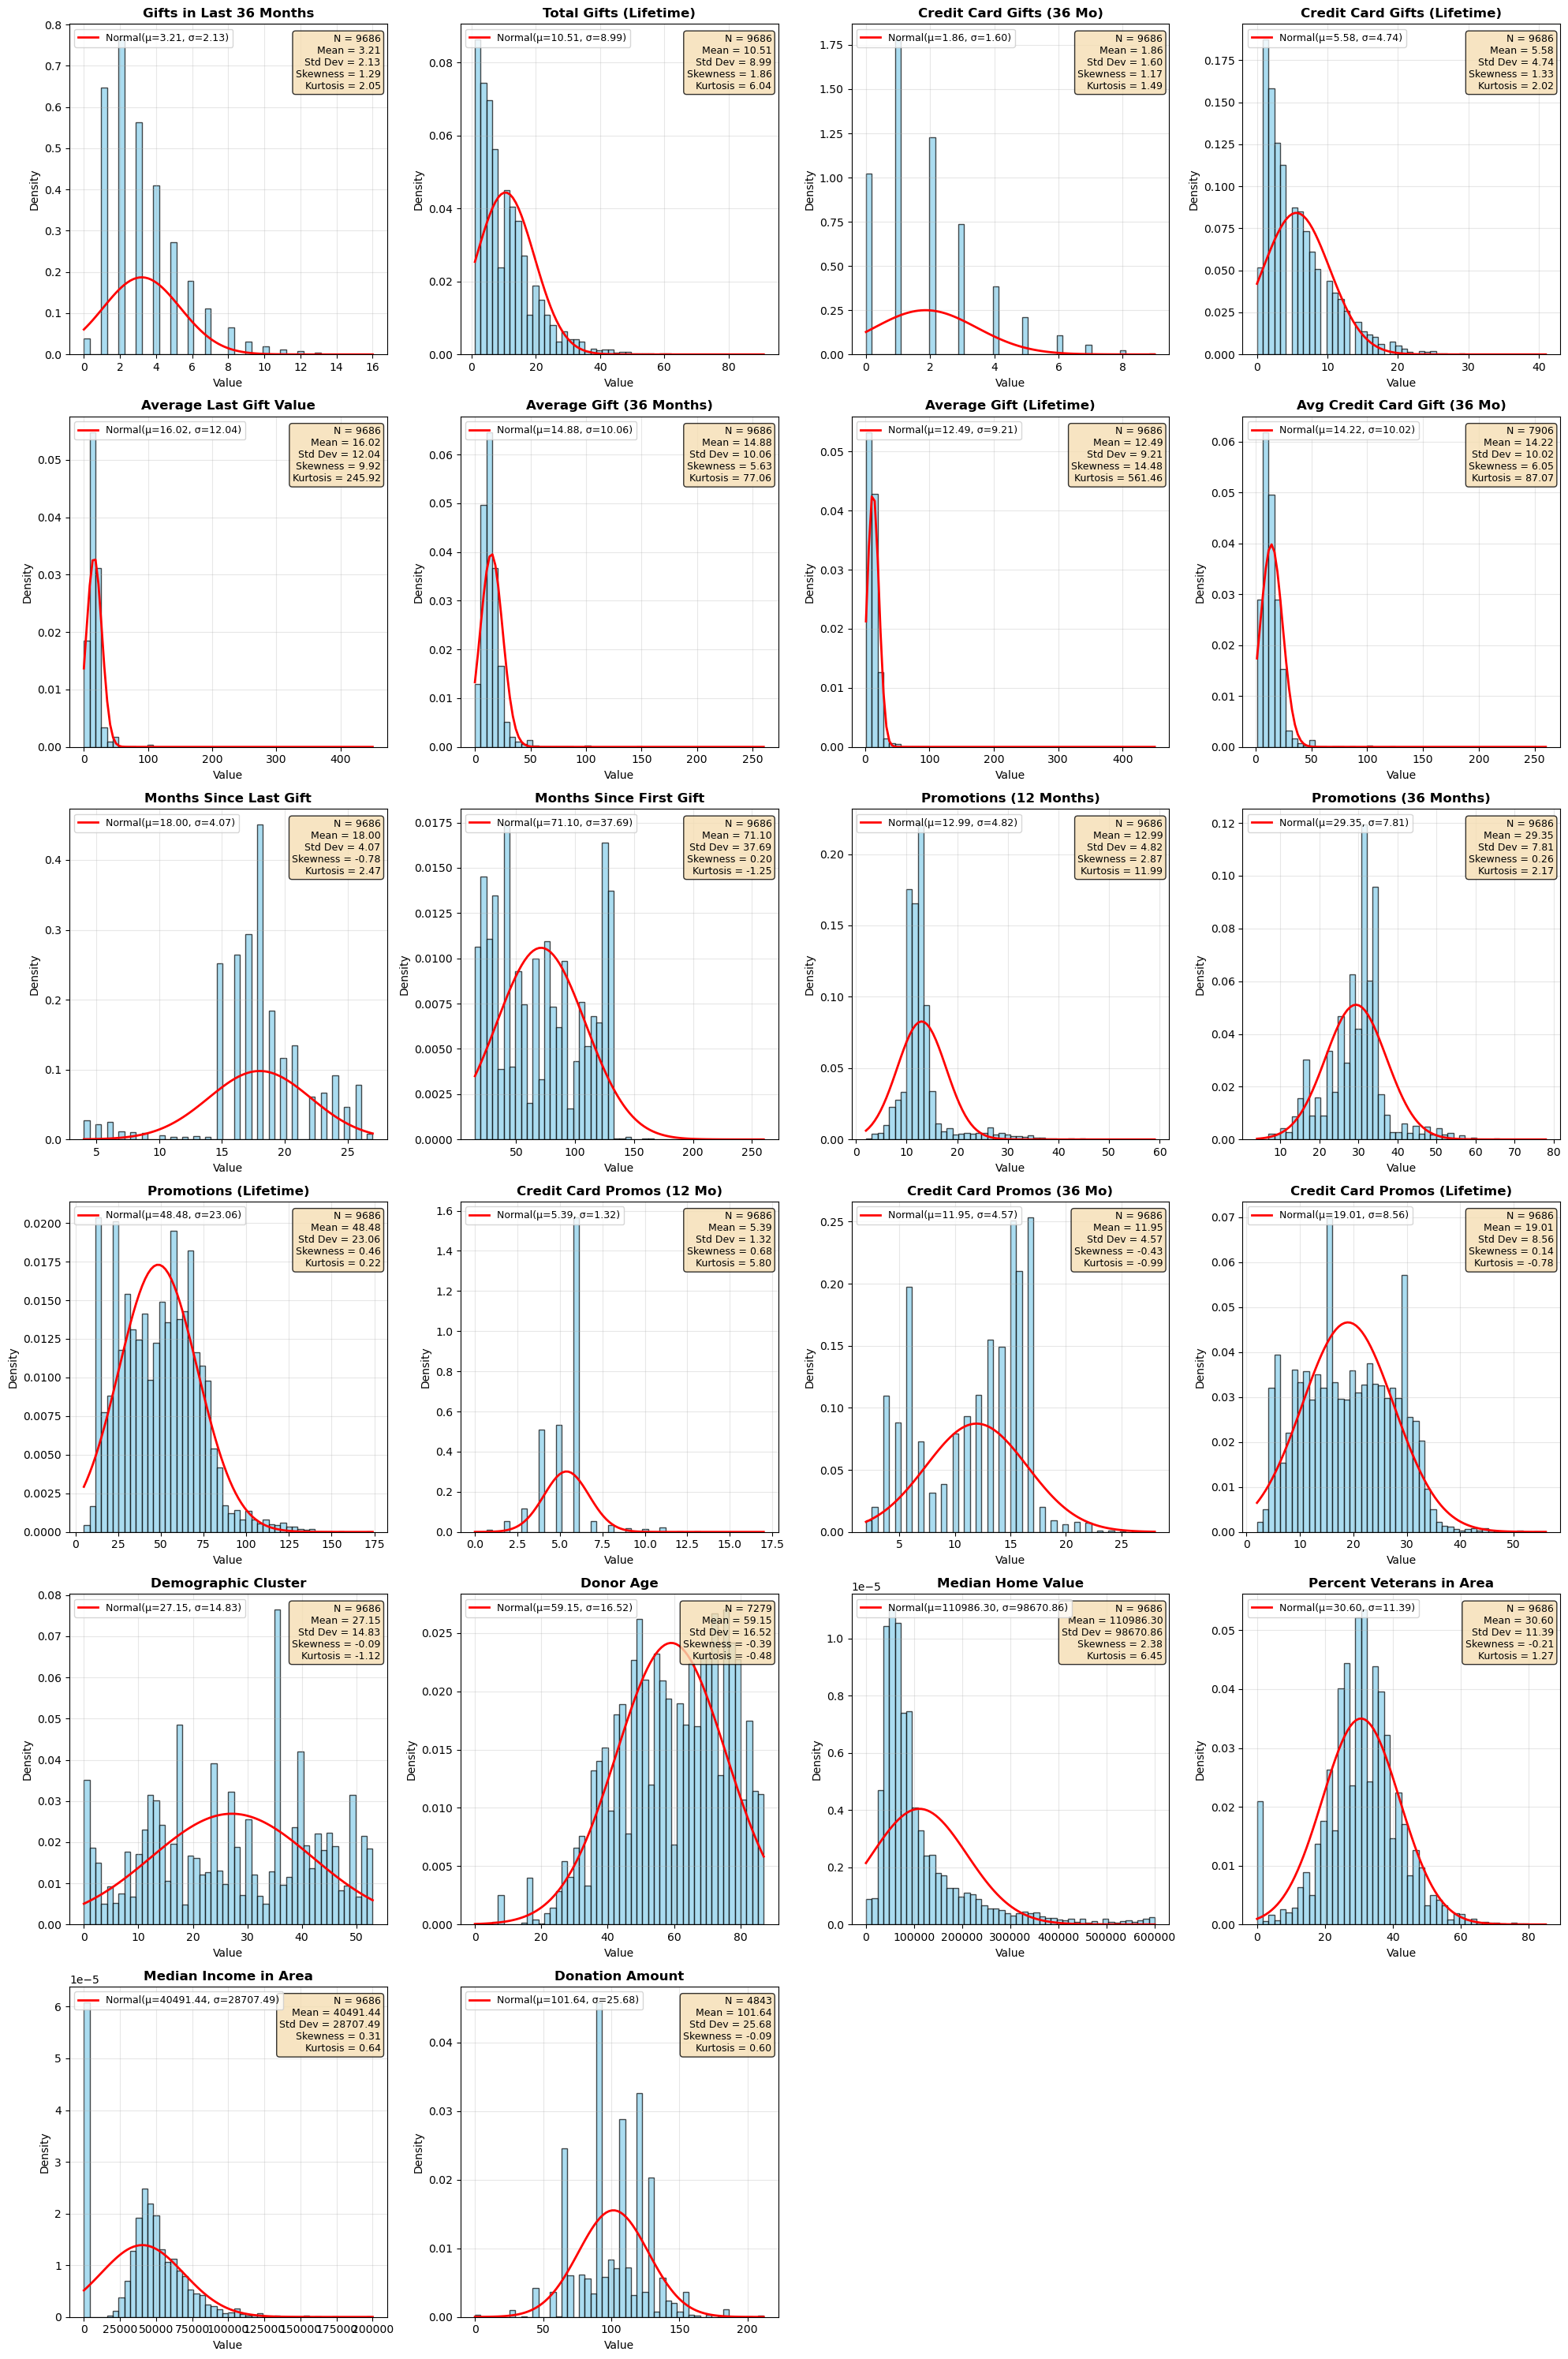

✓ Created histograms for 22 features
✓ Grid layout: 6 rows × 4 columns
✓ Saved as 'feature_distributions.png'


In [75]:
# using density plot instead of percent in histogram

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    data = donor_data[col].dropna()
    
    # Get statistics
    n = len(data)
    mean = data.mean()
    std = data.std()
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)
    
    # Plot histogram
    ax.hist(data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution curve
    x = np.linspace(data.min(), data.max(), 100)
    normal_curve = norm.pdf(x, mean, std)
    ax.plot(x, normal_curve, 'r-', linewidth=2, label=f'Normal(μ={mean:.2f}, σ={std:.2f})')
    
    # Get column description
    description = col_descriptions.get(col, col)
    
    # Set title and labels
    ax.set_title(f'{description}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    
    # Create legend with statistics
    legend_text = f'N = {n}\nMean = {mean:.2f}\nStd Dev = {std:.2f}\nSkewness = {skewness:.2f}\nKurtosis = {kurtosis:.2f}'
    ax.text(0.98, 0.97, legend_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Created histograms for {n_features} features")
print(f"✓ Grid layout: {n_rows} rows × {n_cols} columns")
print(f"✓ Saved as 'feature_distributions.png'")

## Probability Plots (Q-Q Plots): Understanding Normality

### What is a Probability Plot?

A **Probability Plot** (also called **Q-Q Plot** - Quantile-Quantile Plot) is a graphical tool that compares the distribution of your data against a theoretical distribution (usually normal/Gaussian).

---

## Why Use Probability Plots?

### Key Benefits

| Benefit | Explanation |
|---------|-------------|
| **Visual Normality Check** | Quickly see if data follows a normal distribution without statistical tests |
| **Identify Outliers** | Deviations from the line reveal outliers and extreme values |
| **Detect Skewness** | Curved patterns show if data is skewed left or right |
| **Assess Tail Behavior** | See if tails are heavier or lighter than normal distribution |
| **Simple Interpretation** | If points follow the line → data is normal; if not → data deviates |
| **No Assumptions** | Works with any sample size, doesn't require large datasets |

---

## When to Use Probability Plots

### ✅ Use Probability Plots When:

1. **Checking Assumptions for Statistical Tests**
   - Many statistical tests (t-tests, ANOVA, linear regression) assume normality
   - Probability plots help verify this assumption before running tests

2. **Data Preprocessing**
   - Decide if you need to transform data (log, square root, etc.)
   - Identify which features are normally distributed vs. skewed

3. **Quality Control & Manufacturing**
   - Check if product measurements follow expected distribution
   - Identify process issues causing non-normal output

4. **Risk Analysis**
   - Assess if returns/losses follow normal distribution
   - Identify tail risk (extreme events)

5. **Model Diagnostics**
   - Check if regression residuals are normally distributed
   - Validate model assumptions

---

## How to Interpret a Probability Plot

### Perfect Normal Distribution
```
        |     ●
        |    ●
        |   ●
        |  ●
        | ●
        |●
        |________________
        Normal Percentiles
```
**Interpretation:** Points follow the diagonal line perfectly → Data is normally distributed ✓

### Right-Skewed Data (Positive Skew)
```
        |        ●●●
        |      ●●
        |    ●●
        |   ●
        |  ●
        |●
        |________________
        Normal Percentiles
```
**Interpretation:** Points curve upward at the end → Data has a long right tail (high outliers)

### Left-Skewed Data (Negative Skew)
```
        |●
        | ●
        |  ●
        |   ●●
        |     ●●
        |        ●●●
        |________________
        Normal Percentiles
```
**Interpretation:** Points curve downward at the end → Data has a long left tail (low outliers)

### Heavy Tails (High Kurtosis)
```
        |      ●●●
        |    ●●   ●●
        |  ●●       ●●
        | ●           ●
        |●             ●
        |________________
        Normal Percentiles
```
**Interpretation:** Points deviate at both ends → More extreme values than normal distribution

---

## Probability Plot vs Other Normality Tests

| Method | Pros | Cons |
|--------|------|------|
| **Probability Plot** | Visual, intuitive, no assumptions | Subjective interpretation |
| **Histogram** | Easy to understand | Hard to judge normality precisely |
| **Shapiro-Wilk Test** | Statistical, objective | Rejects normality too easily with large samples |
| **Kolmogorov-Smirnov** | Statistical, objective | Sensitive to sample size |
| **Anderson-Darling** | Very sensitive | Complex to interpret |

**Best Practice:** Use probability plots FIRST for visual inspection, then confirm with statistical tests if needed.

---

## Key Takeaways

1. **Straight line = Normal distribution** ✓
2. **Curved line = Non-normal distribution** ✗
3. **Deviations at ends = Outliers or heavy tails**
4. **Use for data exploration and assumption checking**
5. **Combine with histograms and statistical tests for complete analysis**

---

## Example Interpretation

For our donor dataset:
- **GiftAvgLast** will likely show heavy right tail (many small gifts, few large gifts)
- **DemAge** might show more normal distribution
- **GiftTimeLast** might show left skew (recent donations clustered)

The probability plots will visually confirm what we saw in the summary statistics (skewness and kurtosis values).

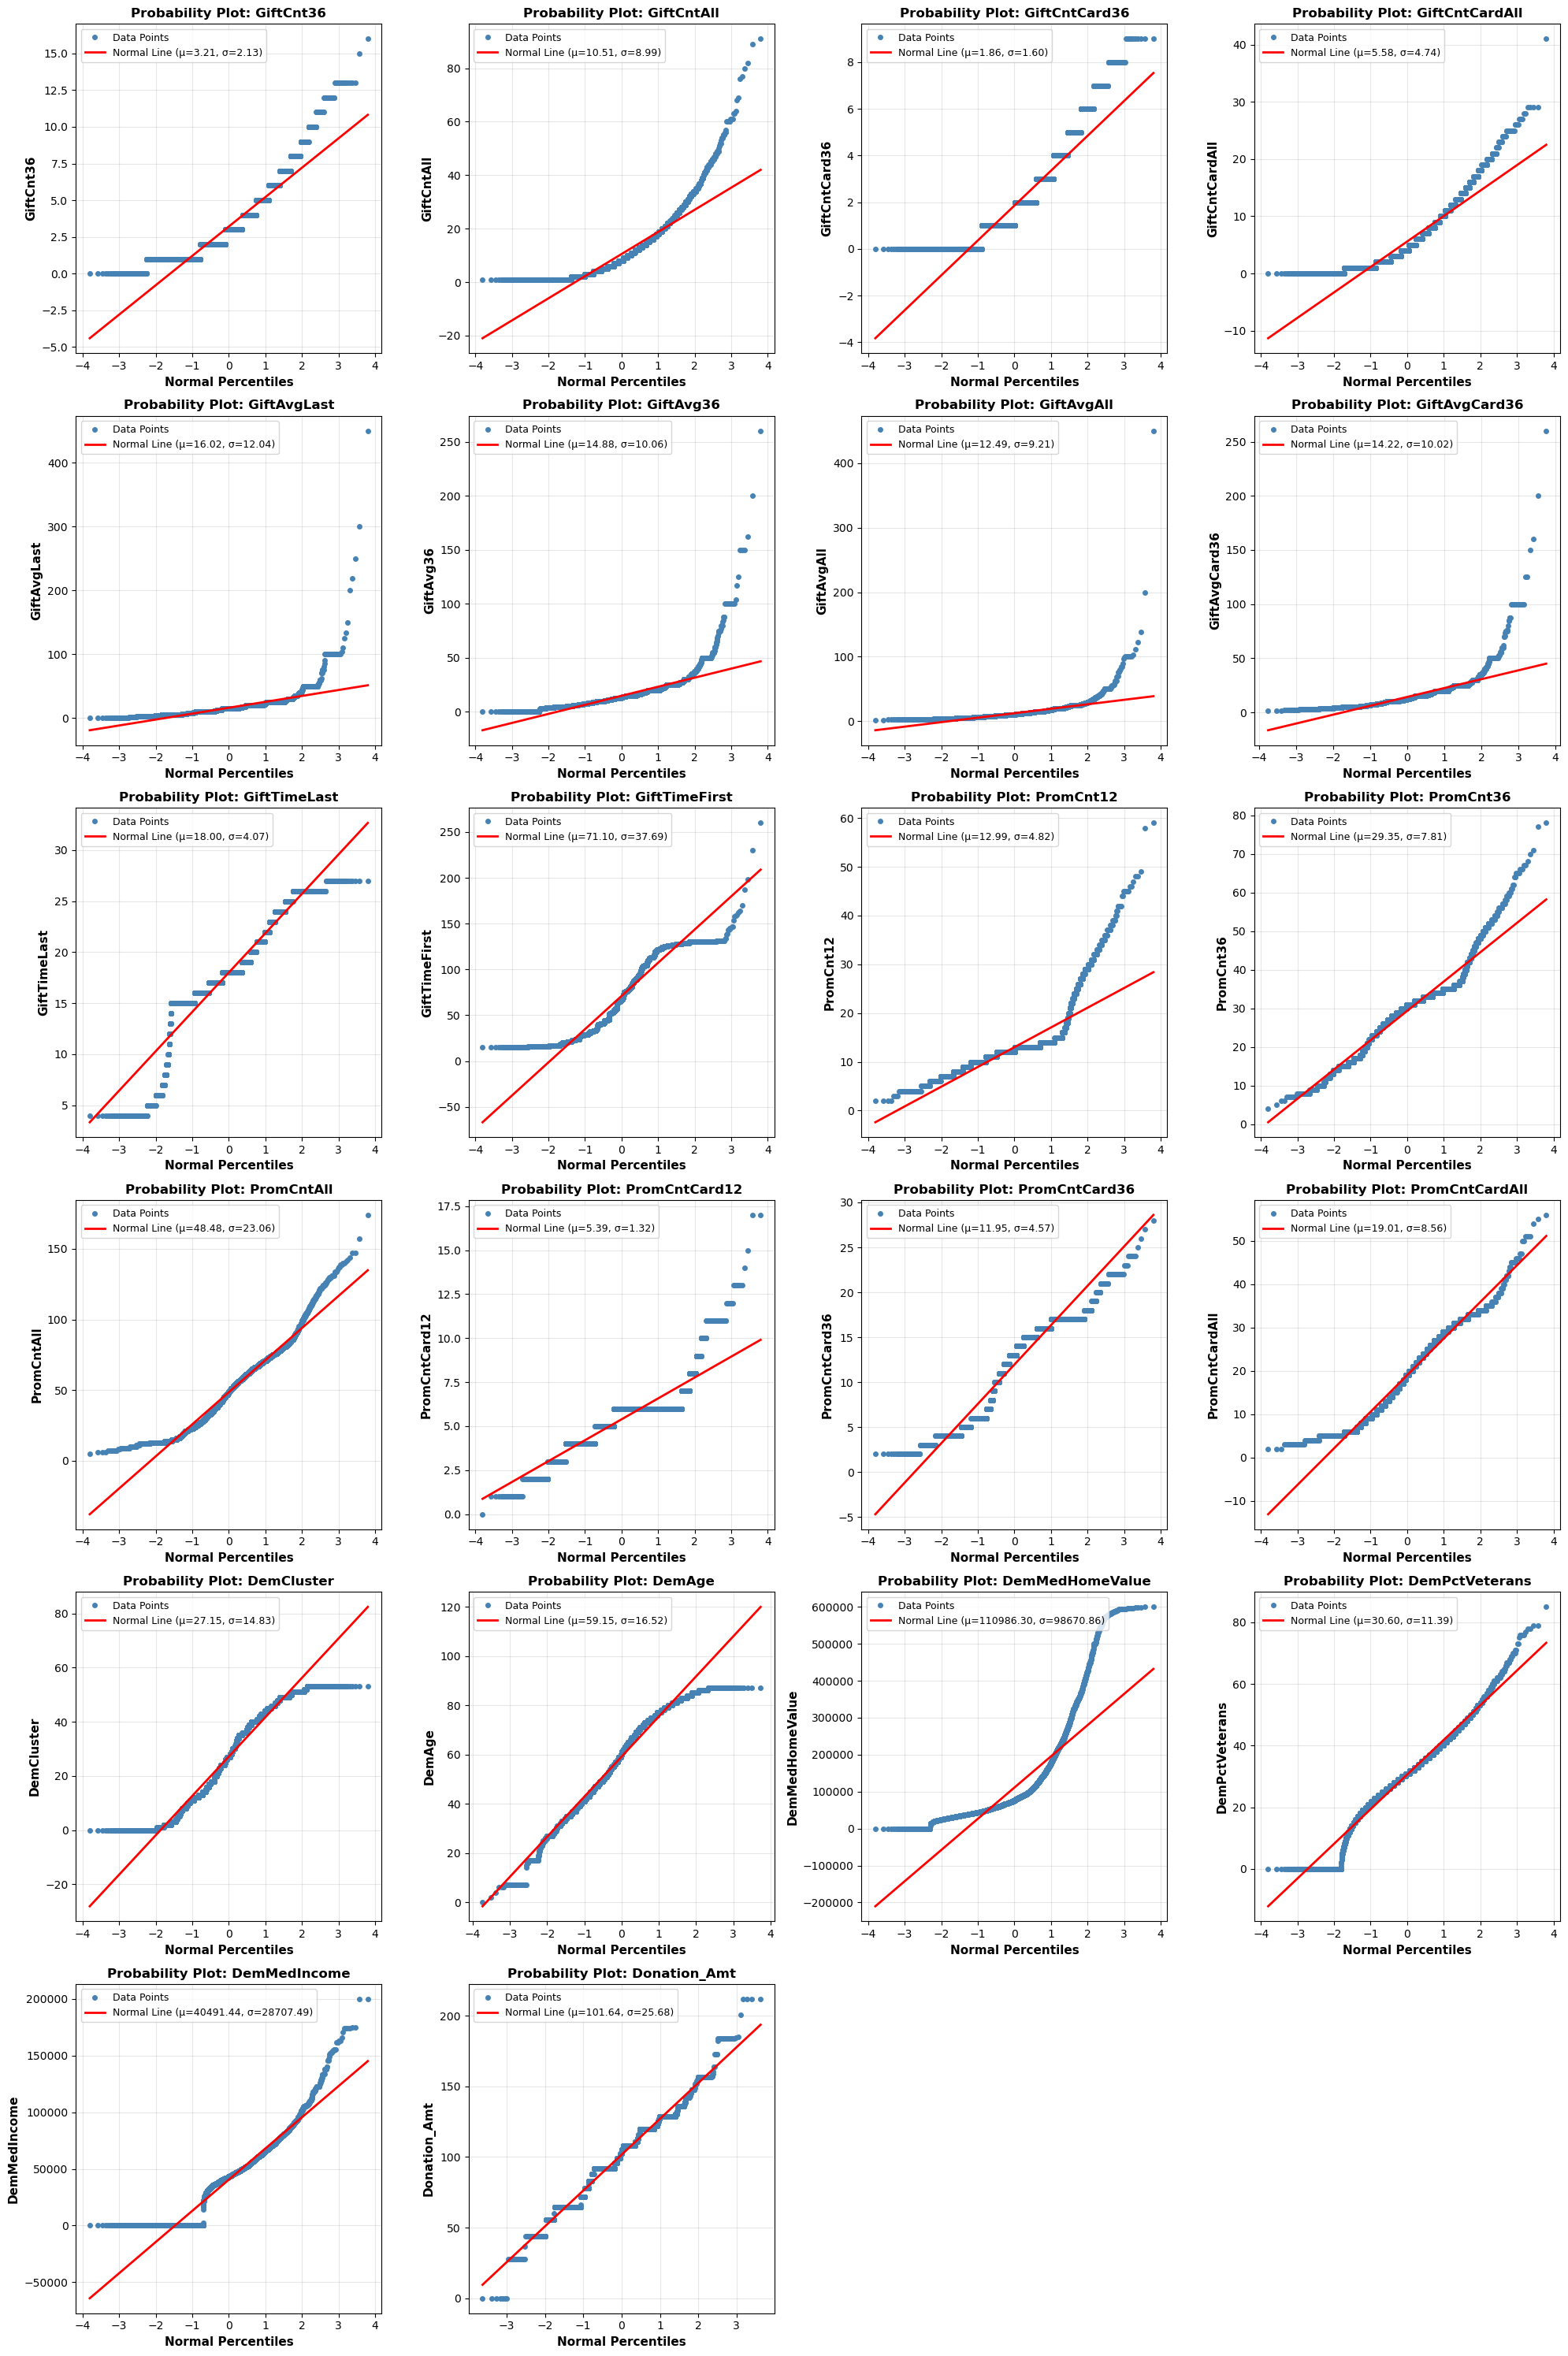

✓ Created probability plots for 22 features
✓ Grid layout: 6 rows × 4 columns
✓ Saved as 'probability_plots.png'

Interpretation Guide:
  • Points on the red line → Data is normally distributed
  • Points curve upward → Right-skewed (positive skew)
  • Points curve downward → Left-skewed (negative skew)
  • Points deviate at ends → Heavy tails or outliers


In [78]:
# Create Q-Q (Probability) Plots for all features

from scipy import stats as sp_stats
import matplotlib.pyplot as plt


# Create subplots - 4 columns, calculate rows needed
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    data = donor_data[col].dropna()
    
    # Get statistics for the normal line
    mean = data.mean()
    std = data.std()
    
    # Create Q-Q plot
    sp_stats.probplot(data, dist="norm", plot=ax)
    
    # Get the line that was drawn
    line = ax.get_lines()[0]
    
    # Customize the plot
    description = col_descriptions.get(col, col)
    
    # Set labels
    ax.set_ylabel(description, fontsize=11, fontweight='bold')
    ax.set_xlabel('Normal Percentiles', fontsize=11, fontweight='bold')
    ax.set_title(f'Probability Plot: {col}', fontsize=12, fontweight='bold')
    
    # Update the normal line label
    ax.get_lines()[1].set_label(f'Normal Line (μ={mean:.2f}, σ={std:.2f})')
    ax.get_lines()[1].set_color('red')
    ax.get_lines()[1].set_linewidth(2)
    
    # Style the data points
    ax.get_lines()[0].set_marker('o')
    ax.get_lines()[0].set_markersize(4)
    ax.get_lines()[0].set_color('steelblue')
    ax.get_lines()[0].set_linestyle('None')
    ax.get_lines()[0].set_label('Data Points')
    
    # Add legend and grid
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('probability_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Created probability plots for {n_features} features")
print(f"✓ Grid layout: {n_rows} rows × {n_cols} columns")
print(f"✓ Saved as 'probability_plots.png'")
print(f"\nInterpretation Guide:")
print(f"  • Points on the red line → Data is normally distributed")
print(f"  • Points curve upward → Right-skewed (positive skew)")
print(f"  • Points curve downward → Left-skewed (negative skew)")
print(f"  • Points deviate at ends → Heavy tails or outliers")

## One-Way Frequency Charts: Understanding Categorical Data

### What is a One-Way Frequency Chart?

A **One-Way Frequency Chart** (also called **Bar Chart** or **Frequency Distribution**) displays the count or percentage of observations in each category of a single categorical variable.

---

## Why One-Way Frequency Charts Are Useful

### Key Benefits

| Benefit | Explanation |
|---------|-------------|
| **Data Distribution** | See how observations are distributed across categories |
| **Imbalanced Data** | Identify if some categories are over/under-represented |
| **Business Insights** | Understand customer segments, response rates, demographics |
| **Data Quality** | Spot missing values, unexpected categories, or data entry errors |
| **Decision Making** | Inform marketing strategies, resource allocation, targeting |
| **Simple & Clear** | Easy to understand for all stakeholders, no statistical background needed |
| **Actionable** | Directly shows which segments need attention |

---

## When to Use One-Way Frequency Charts

### ✅ Use When:

1. **Exploring Categorical Variables**
   - First step in understanding categorical data
   - See what categories exist and their prevalence

2. **Assessing Data Balance**
   - Check if classes are balanced (important for machine learning)
   - Identify if sampling is needed

3. **Business Reporting**
   - Show customer segments to stakeholders
   - Report on campaign response rates
   - Display demographic breakdowns

4. **Data Quality Checks**
   - Verify data entry accuracy
   - Identify unexpected or missing categories
   - Spot data collection issues

5. **Target Variable Analysis**
   - Understand class distribution in classification problems
   - Assess if target is imbalanced

---

## Interpretation Guide

### Balanced Distribution
```
Category A: ████████ 25%
Category B: ████████ 25%
Category C: ████████ 25%
Category D: ████████ 25%
```
**Interpretation:** Equal representation across all categories ✓

### Imbalanced Distribution
```
Category A: ████████████████████ 60%
Category B: ███████ 20%
Category C: ███ 10%
Category D: ██ 10%
```
**Interpretation:** Category A dominates; may need special handling in modeling

### Sparse Distribution
```
Category A: ████████████████████████ 80%
Category B: ████ 15%
Category C: ██ 5%
```
**Interpretation:** One category overwhelms others; consider grouping or weighting

---

## For Our Donor Dataset

### Variables We'll Analyze:

| Variable | Type | Purpose |
|----------|------|---------|
| **StatusCat96NK** | Target | Donor response status (A, E, S, F, N, L) |
| **StatusCatStarAll** | Target | Binary engagement indicator (0 or 1) |
| **DemGender** | Demographic | Gender distribution (M, F, U) |
| **DemHomeOwner** | Demographic | Home ownership status (H, U) |

### What We'll Learn:

- **StatusCat96NK:** Which donor segments are most common?
- **StatusCatStarAll:** Is the target balanced for classification?
- **DemGender:** Gender representation in donor base
- **DemHomeOwner:** Home ownership patterns

---

## Key Insights to Look For

1. **Class Imbalance** - If target variable is imbalanced, we may need:
   - Stratified sampling
   - Class weights in models
   - Oversampling/undersampling

2. **Missing Values** - "U" (Unknown) categories indicate:
   - Data quality issues
   - Need for imputation
   - Potential bias

3. **Segment Size** - Small segments may need:
   - Grouping with similar categories
   - Special attention in analysis
   - Separate modeling strategies

4. **Business Relevance** - Frequency distribution informs:
   - Marketing targeting
   - Resource allocation
   - Campaign strategies

---

## One-Way Frequency Chart vs Other Visualizations

| Chart Type | Best For | Limitation |
|-----------|----------|-----------|
| **Bar Chart** | Comparing frequencies across categories | Can't show relationships |
| **Pie Chart** | Showing proportions of a whole | Hard to compare similar sizes |
| **Table** | Exact numbers and percentages | Less visual impact |
| **Stacked Bar** | Comparing multiple variables | Can get cluttered |

**Best Practice:** Use bar charts for one-way frequency analysis - they're clear, professional, and easy to interpret.

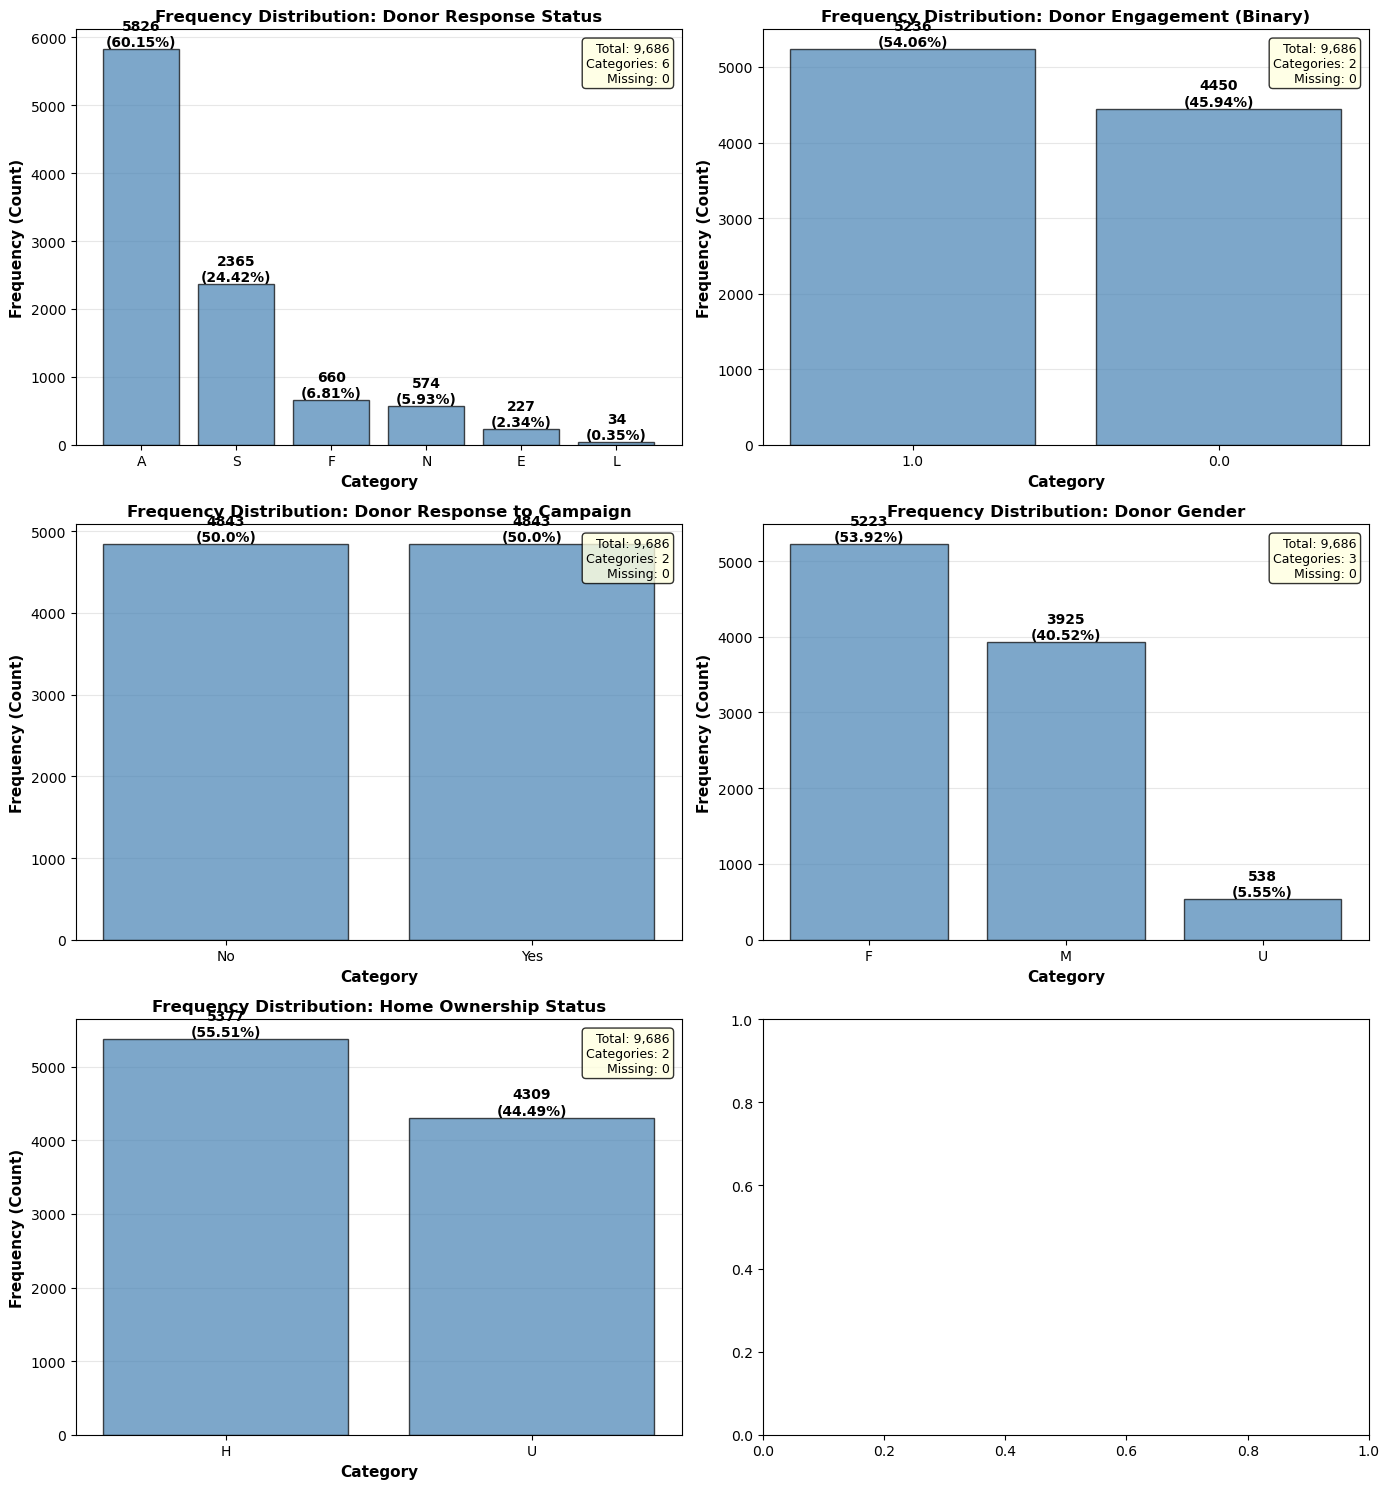

ONE-WAY FREQUENCY ANALYSIS

DONOR RESPONSE STATUS
----------------------------------------------------------------------
Category  Count  Percentage  Cumulative %
       A   5826       60.15         60.15
       S   2365       24.42         84.57
       F    660        6.81         91.38
       N    574        5.93         97.31
       E    227        2.34         99.65
       L     34        0.35        100.00

Missing Values: 0


DONOR ENGAGEMENT (BINARY)
----------------------------------------------------------------------
 Category  Count  Percentage  Cumulative %
      1.0   5236       54.06         54.06
      0.0   4450       45.94        100.00

Missing Values: 0


DONOR RESPONSE TO CAMPAIGN
----------------------------------------------------------------------
Category  Count  Percentage  Cumulative %
      No   4843        50.0          50.0
     Yes   4843        50.0         100.0

Missing Values: 0


DONOR GENDER
-----------------------------------------------------------

In [77]:
# Create One-Way Frequency Charts for Categorical Variables

import matplotlib.pyplot as plt
import seaborn as sns

# Columns to analyze
categorical_cols = ['StatusCat96NK', 'StatusCatStarAll', 'Response', 'DemGender', 'DemHomeOwner']

# Column descriptions
col_descriptions = {
    'StatusCat96NK': 'Donor Response Status',
    'StatusCatStarAll': 'Donor Engagement (Binary)',
    'Response': 'Donor Response to Campaign',
    'DemGender': 'Donor Gender',
    'DemHomeOwner': 'Home Ownership Status'
}

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    
    # Get value counts
    value_counts = donor_data[col].value_counts().sort_values(ascending=False)
    percentages = (value_counts / len(donor_data) * 100).round(2)
    
    # Create bar chart
    bars = ax.bar(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    
    # Add percentage labels on top of bars
    for i, (bar, pct) in enumerate(zip(bars, percentages.values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({pct}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Set labels and title
    description = col_descriptions.get(col, col)
    ax.set_title(f'Frequency Distribution: {description}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Category', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency (Count)', fontsize=11, fontweight='bold')
    
    # Set x-axis labels
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, fontsize=10)
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Add summary statistics box
    summary_text = f'Total: {len(donor_data):,}\nCategories: {len(value_counts)}\nMissing: {donor_data[col].isna().sum()}'
    ax.text(0.98, 0.97, summary_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('frequency_charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("=" * 70)
print("ONE-WAY FREQUENCY ANALYSIS")
print("=" * 70)

for col in categorical_cols:
    print(f"\n{col_descriptions.get(col, col).upper()}")
    print("-" * 70)
    
    value_counts = donor_data[col].value_counts()
    percentages = (value_counts / len(donor_data) * 100).round(2)
    
    # Create summary table
    summary_df = pd.DataFrame({
        'Category': value_counts.index,
        'Count': value_counts.values,
        'Percentage': percentages.values,
        'Cumulative %': percentages.cumsum().values
    })
    
    print(summary_df.to_string(index=False))
    print(f"\nMissing Values: {donor_data[col].isna().sum()}")
    print()

print("=" * 70)
print("✓ Created frequency charts for 4 categorical variables")
print("✓ Saved as 'frequency_charts.png'")
print("=" * 70)

## Analysis Summary & Recommendations

### Key Findings from Distribution Analysis

#### 1. **Highly Skewed Features** (Right-skewed)
- **GiftAvgLast**: Extreme skewness (207.18), kurtosis (52,894.91)
  - Most donors give $10-20, few give $10,000
  - Recommendation: Consider log transformation for modeling
  
- **GiftAvg36**, **GiftAvgCard36**: Also highly skewed
  - Similar pattern: concentrated at low values with extreme outliers
  - Recommendation: Log transformation recommended

#### 2. **Normally Distributed Features** (Good for modeling)
- **GiftTimeLast**: Relatively normal distribution
- **GiftTimeFirst**: Approximately normal
- **DemAge**: Near-normal (with some missing values)
- **PromCnt36**: Approximately normal

#### 3. **Features with Missing Values**
| Feature | Missing | % Missing | Action |
|---------|---------|-----------|--------|
| GiftAvgCard36 | 1,780 | 18.4% | Impute or drop |
| DemAge | 2,407 | 24.8% | Impute with median/mean |
| Rep_DemMedIncome | 2,357 | 24.3% | Already imputed |
| log_GiftCnt36 | 118 | 1.2% | Minimal impact |

#### 4. **Target Variable Distribution**
- **Response**: Perfectly balanced (50% Yes, 50% No)
  - Good for classification modeling
  - No class imbalance issues
  
- **Donation_Amt**: 50% missing (expected for non-responders)
  - Only available for Response='Yes'
  - Right-skewed distribution
  - Recommendation: Log transformation for regression

### Recommendations for Modeling

#### Data Preprocessing
1. **Handle Missing Values**
   - DemAge: Impute with median (24.8% missing)
   - GiftAvgCard36: Impute or drop (18.4% missing)
   - Rep_DemMedIncome: Already handled

2. **Feature Transformation**
   - Apply log transformation to: GiftAvgLast, GiftAvg36, GiftAvgCard36
   - Reduces skewness and improves model performance
   - Helps with linear models (regression, logistic regression)

3. **Feature Scaling**
   - Standardize features for distance-based models (KNN, SVM)
   - Not needed for tree-based models (Random Forest, XGBoost)

#### Model Selection

**For Classification (Response prediction)**
- Logistic Regression: Good baseline
- Random Forest: Handles non-linear relationships
- Gradient Boosting: Often best performance
- Note: Balanced classes = no need for class weights

**For Regression (Donation_Amt prediction)**
- Linear Regression: After log transformation
- Random Forest: Handles outliers well
- Gradient Boosting: Best for complex patterns
- Note: Consider log-transforming target variable

### Next Steps
1. ✅ Exploratory Data Analysis (completed)
2. → Data Preprocessing & Feature Engineering
3. → Model Development & Training
4. → Model Evaluation & Validation
5. → Hyperparameter Tuning
6. → Final Model Deployment